# Verify Our Temperatures with Measured Ones from Austria

We want to know which method is the best to create approximate temperatures from the given data from ERA5. We create data using different methods and compare them with actual temperatures from Austria.

In [1]:
import csv
import json

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import netCDF4 as nc
import numpy as np
import pandas as pd
from shapely import Point
import shapefile
import xarray as xr

In [16]:
# Load ERA5 data and crop it
era5_data = xr.open_dataset('era5_data.nc')

In [17]:
# Min and max latitude and longitudes
lat_min, lat_max = era5_data.latitude.min(), era5_data.latitude.max()
lon_min, lon_max = era5_data.longitude.min(), era5_data.longitude.max()

In [29]:
# Numpy arrays for latitude and longitude
era5_lat_vals = np.asarray(era5_data.variables['latitude'])
era5_lon_vals = np.asarray(era5_data.variables['longitude'])
# Timestamps for the data as strings
era5_time_vals = np.vectorize(lambda x: pd.to_datetime(x).strftime('%Y-%m-%dT%H:00+00:00'))(era5_data.variables['time'])

temperatures_by_coords = np.transpose(era5_data.variables['t2m'], axes=[1, 2, 0])

In [19]:
# Load mean heights data and crop it
mean_heights_data = nc.Dataset('mean_heights_data.nc', 'r', format='NETCDF4')

In [20]:
mean_heights_data['mean_height']

<class 'netCDF4.Variable'>
float64 mean_height(latitude, longitude)
    _FillValue: nan
unlimited dimensions: 
current shape = (17, 33)
filling on

In [21]:
# Numpy arrays for latitude and longitude
lat_vals = np.asarray(mean_heights_data.variables['latitude'])
lon_vals = np.asarray(mean_heights_data.variables['longitude'])

In [23]:
# Load STD Stations-Metadaten.csv
file = open('STD Stations-Metadaten.csv', 'r')
reader = csv.DictReader(file)

# stations by ID
stations = {}

for row in reader:
    lat = float(row["Breite [°N]"])
    lon = float(row["Länge [°E]"])
    elev = float(row["Höhe [m]"])
    name = row["Stationsname"]

    # indexes in median/mean height arrays
    lat_idx = np.abs(lat_vals - lat).argmin()
    lon_idx = np.abs(lon_vals - lon).argmin()

    # ERA5 indexes
    era5_lat_idx = np.abs(era5_lat_vals - lat).argmin()
    era5_lon_idx = np.abs(era5_lon_vals - lon).argmin()

    # calculate median height
    median_height = mean_heights_data.variables['median_height'][lat_idx][lon_idx]

    # calculate mean height
    mean_height = mean_heights_data.variables['mean_height'][lat_idx][lon_idx]

    # calculate mode height
    mode_height = mean_heights_data.variables['mode_height'][lat_idx][lon_idx]

    stations[int(row['id'])] = {
        "geometry": Point(lon, lat),
        "elevation": elev,
        "median_height": median_height,
        "mean_height": mean_height,
        "mode_height": mode_height,
        "era5_lat_idx": era5_lat_idx,
        "era5_lon_idx": era5_lon_idx,
        "name": name,
    }

In [24]:
# Now on with JSON data
json_data = json.load(open('STD Datensatz_19900101T0000_19991231T2300.json', 'r'))

# create series
time = pd.Series(json_data['timestamps'], dtype='string')

In [25]:
# get locations from JSON data, also aggregate JSON data into a list
locations = []
data = []

for item in json_data['features']:
    station_id = int(item['properties']['station'])
    p = Point(item['geometry']['coordinates'])
    locations.append(stations[station_id])

    data.append(item['properties']['parameters']['TTX']['data'])

locations = gpd.GeoDataFrame(locations, crs='EPSG:4326')

In [26]:
# JSON data to GeoDataFrame
df = gpd.GeoDataFrame(data=data, columns=time, geometry=locations['geometry'])
# merge location data into GeoDataFrame
df = df.merge(locations, on='geometry', how='inner')

In [27]:
# Total number of days
days_total = len(era5_time_vals)

# helper to create plot data
def get_deviations(df, label):
    dp = len(df)
    v_mean = df.mean()
    v_max = df.max()
    return {
        "label": label,
        "data_points": f"$\\mu={dp}$",
        "mean_max": "$\\overline{x}=" + f"{v_mean:.2f}$" + ", $x_{max}=" + f"{v_max:.2f}$",
        "le_1deg": (df <= 1.).sum()/len(df),
        "le_2deg": (df <= 2.).sum()/len(df),
        "le_3deg": (df <= 3.).sum()/len(df),
        "all": 1.,
        "dp": dp,
        "mean": v_mean,
        "max": v_max,
    }

# labels
lbls = [
    {"field": "all", "label": "> 3°C"},
    {"field": "le_3deg", "label": "≤ 3°C"},
    {"field": "le_2deg", "label": "≤ 2°C"},
    {"field": "le_1deg", "label": "≤ 1°C"},
]

In [28]:
w = shapefile.Writer(target='verify_station_data_austria_vs_era5.shp', shapeType=shapefile.POINT, autoBalance=True)
w.field("station", "C")
w.field("height", "N", decimal=0)
w.field("height_mean", "N", decimal=0)
w.field("points", "N", decimal=0)
w.field("perc_1deg", "N", decimal=2)
w.field("perc_2deg", "N", decimal=2)
w.field("perc_3deg", "N", decimal=2)
w.field("mean", "N", decimal=2)
w.field("max", "N", decimal=2)

87648 Days in Total


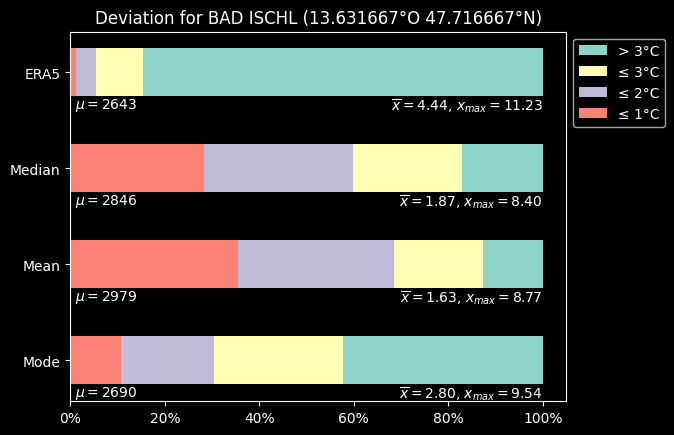

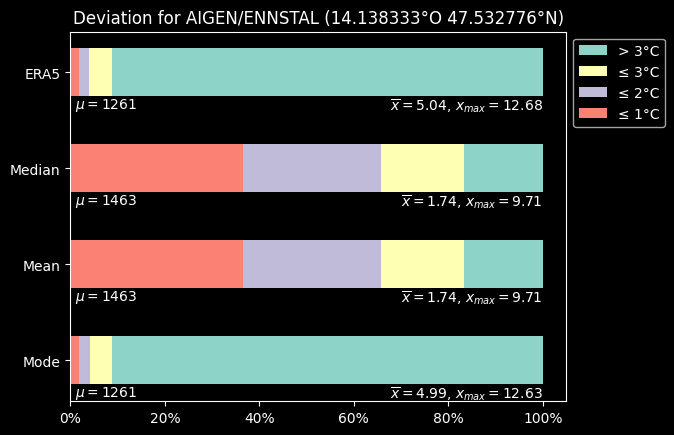

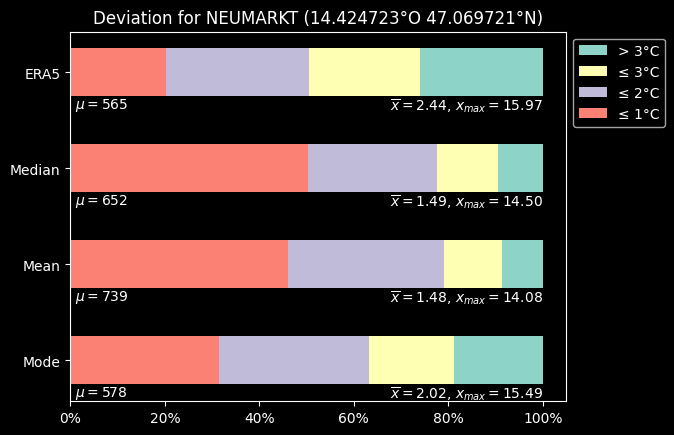

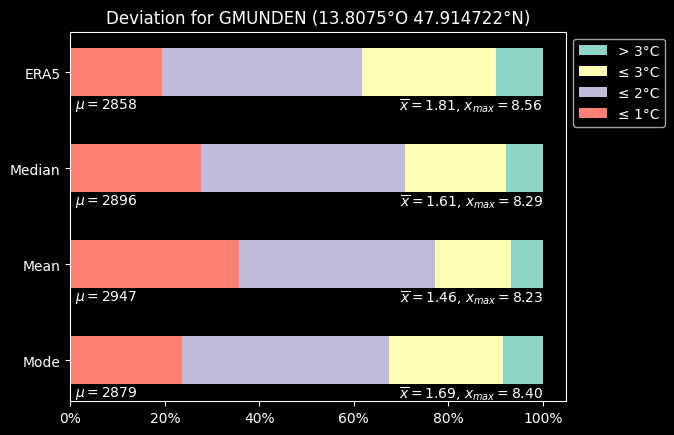

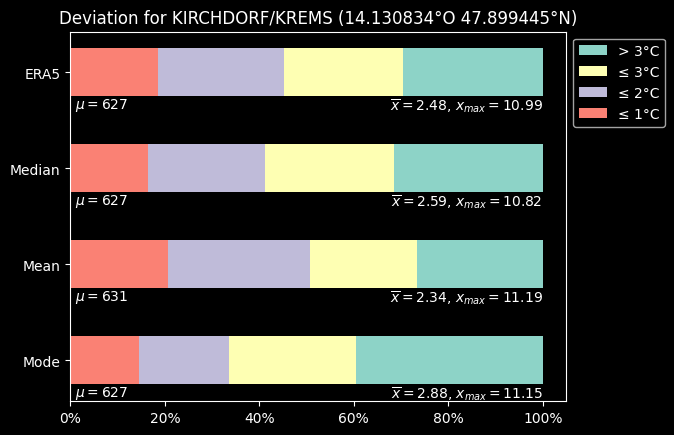

In [30]:
# Print the total number of days as reference
print(days_total, "Days in Total")

for _, row in df.iterrows():
    deviation_measured_era5 = np.full(len(era5_time_vals), np.nan)
    deviation_measured_median = np.full(len(era5_time_vals), np.nan)
    deviation_measured_mean = np.full(len(era5_time_vals), np.nan)
    deviation_measured_mode = np.full(len(era5_time_vals), np.nan)

    # get temperatures for this station (by coordinates) - for all timestamps
    temperatures_by_ts = temperatures_by_coords[row['era5_lat_idx']][row['era5_lon_idx']]-273.15
    has_valid_temps = False

    # get all era5 data temperatures for this station
    for i in range(len(era5_time_vals)):
        temp = era5_time_vals[i]
        measured_temp_station = row[temp]
        # skip invalid or NaN data
        if measured_temp_station is None or np.isnan(measured_temp_station):
            continue
        has_valid_temps = True

        # get right coordinates in the era5 data and deduct 273.15 to get Celsius
        calculated_temp_era5 = temperatures_by_ts[i]

        # adjust measured temperature to heights
        adjusted_by_median = calculated_temp_era5 + (row['median_height'] - row['elevation']) / 100 * 0.6
        adjusted_by_mean = calculated_temp_era5 + (row['mean_height'] - row['elevation']) / 100 * 0.6
        adjusted_by_mode = calculated_temp_era5 + (row['mode_height'] - row['elevation']) / 100 * 0.6

        if calculated_temp_era5 >= 25. or measured_temp_station >= 25.:
            deviation_measured_era5[i] = abs(calculated_temp_era5 - measured_temp_station)
        if calculated_temp_era5 >= 25. or measured_temp_station >= 25. or adjusted_by_median >= 25.:
            deviation_measured_median[i] = abs(adjusted_by_median - measured_temp_station)
        if calculated_temp_era5 >= 25. or measured_temp_station >= 25. or adjusted_by_mean >= 25.:
            deviation_measured_mean[i] = abs(adjusted_by_mean - measured_temp_station)
        if calculated_temp_era5 >= 25. or measured_temp_station >= 25. or adjusted_by_mode >= 25.:
            deviation_measured_mode[i] = abs(adjusted_by_mode - measured_temp_station)

    if has_valid_temps:
        # print(row['name'], row['geometry'])

        # remove NaN values
        deviation_measured_era5 = deviation_measured_era5[~np.isnan(deviation_measured_era5)]
        deviation_measured_median = deviation_measured_median[~np.isnan(deviation_measured_median)]
        deviation_measured_mean = deviation_measured_mean[~np.isnan(deviation_measured_mean)]
        deviation_measured_mode = deviation_measured_mode[~np.isnan(deviation_measured_mode)]

        deviations = pd.DataFrame([
            get_deviations(deviation_measured_era5, "ERA5"),
            get_deviations(deviation_measured_median, "Median"),
            get_deviations(deviation_measured_mean, "Mean"),
            get_deviations(deviation_measured_mode, "Mode"),
        ])

        fig, ax = plt.subplots()
        bottom = np.zeros(len(deviations))

        for f in lbls:
            ax.barh(deviations['label'], deviations[f['field']], 0.5, label=f['label'], left=bottom)

        ax.set_title(f"Deviation for {row['name']} ({row['geometry'].x}°O {row['geometry'].y}°N)")
        ax.legend(bbox_to_anchor=(1., 1.))
        ax.invert_yaxis()
        ax.xaxis.set_major_formatter(mtick.PercentFormatter(1))

        rects = ax.patches

        for rect, points, mean_max in zip(rects, deviations['data_points'], deviations['mean_max']):
            y = rect.get_y()+rect.get_height()
            ax.text(
                0.01, y, points, ha="left", va="top"
            )
            ax.text(
                rect.get_width(), y, mean_max, ha="right", va="top"
            )

        plt.show()

        # add to Shapefile
        w.point(row['geometry'].x, row['geometry'].y)
        w.record(row['name'], row['elevation'], row['mean_height'], deviations['dp'][2], deviations['le_1deg'][2]*100, deviations['le_2deg'][2]*100, deviations['le_2deg'][2]*100, deviations['mean'][2], deviations['max'][2])

w.close()

So, if we look at the data above, we can see that the ERA5 data generally has a higher deviation compared to the other methods. This is especially true for stations in valleys. Median and mean seem relatively close to measured temperatures, so it seems possible to use one of these methods to determine the temperatures in the simulation. There is still some bias. We will take the mean!